### note
<br/>

### note name

In [1]:
# pip install ipynbname

import ipynbname
nb_name = ipynbname.name()
nb_path = ipynbname.path()

nb_name

'2Samples Classical_GRU_P27 SEEDs_ini_2'

## Hyper parameters

In [2]:
SEED = 2
# SEEDs = range(10) # 0~9
L_RATE = 0.2 # 0.2
N_STEPS = 1000000
NUM_SEEDs = 50

In [3]:
from jax.config import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import pennylane as qml
from jax.example_libraries import optimizers
from jax.example_libraries import stax
from jax import value_and_grad
from jax import lax

import optax
# from functools import partial
import time
import matplotlib.pyplot as plt
import pickle


from SQGRU_j7x import SQGRU, qgru
from Classical_RNN import simple_rnn, gru, count_parameters

### force to use cpu

In [4]:
jax.config.update('jax_platform_name', 'cpu')

In [5]:
qml.version()

'0.31.1'

## Oscillations

In [6]:
def damped_shm(fre, damp):
    amp = 0.7
    num_data = 151
    x = jnp.array(range(num_data))
    y = jnp.sin(x*fre)*jnp.exp(x*damp)*amp

    return y

In [7]:
osc1 = damped_shm(0.4, 0)
osc2 = damped_shm(0.6, -0.02)

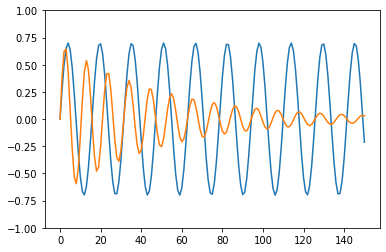

In [8]:
plt.plot(osc1)
plt.plot(osc2)
plt.ylim(-1,1)
plt.show()

In [9]:
oscillations = jnp.array([osc1,osc2])
true_data = jnp.expand_dims(oscillations, 2)
train_input = true_data[:,0:100,:]
train_target = true_data[:,1:101,:]

## Model
### Hyper parameters

In [10]:
# model parameters
OUT_DIM = 2

In [11]:
init_fun, qgru_rnn = stax.serial(gru(OUT_DIM, sequence_out=True), stax.Dense(1))

In [12]:
key = jax.random.PRNGKey(SEED)
key1, key2 = jax.random.split(key, num=2)
_, params = init_fun(key1, jnp.shape(train_input))

In [13]:
count_parameters(params)

27

## Train

In [14]:
step_size = L_RATE
optimizer = optax.adam(step_size)
opt_state = optimizer.init(params)

In [15]:

@jax.jit
def loss_fn(params, xs, ys):
#     prediction = qgru_rnn(params, xs)[:,:,0:1]
    prediction = qgru_rnn(params, xs)
#     prediction = cls_predict(xs, 10, params)
    
    return jnp.mean((prediction - ys)**2) # the prediction shape


# def update(i_step, params, xs, ys, opt_state):
#     loss, grads = value_and_grad(loss_fn)(params, xs, ys)
#     updates, opt_state = optimizer.update(grads, opt_state)
#     params = optax.apply_updates(params, updates)
#     return params, opt_state, loss


In [16]:
minLoss = 1000
best_params = params
lossList = []
loc_params_list = []
reset_steps = []

In [17]:
def ck_lr(old_lr, new_lr):
    d_lr = old_lr - new_lr
    return d_lr >= 0 and d_lr/new_lr < 1e-2

### prediction

In [18]:
_, qgru_rnn2 = stax.serial(gru(OUT_DIM, sequence_out=True), stax.Dense(1))

In [19]:
@jax.jit
def jit_rnn(params, inputs):
    return qgru_rnn2(params, inputs)

In [20]:
true1 = true_data.squeeze()[:,0:100]
true2 = true_data.squeeze()[:,100:]
xs = train_input

In [21]:
# for classical rnn to predict the trend
def cls_predict(inp, pred_length, params):
    ys = jit_rnn(params, inp)
    new_inp = inp
    for _ in range(pred_length-1):
        new_inp = jnp.concatenate([new_inp, ys[:,-1:]], axis=1)
        ys = jit_rnn(params, new_inp)
    return ys

### start

In [22]:
update_lr = True
lr_factor = 1
locLossList = [1000,1000,1000]
locLoss = 1000
loc_params = params



start = time.time()
for i in range(N_STEPS):
    
    if update_lr != 0:
        if update_lr < 0:
            params = loc_params
        else:
            locLossList = [1000,1000,1000]
            locLoss = 1000
            loc_params_list.append(loc_params)
            reset_steps.append(i)
            # reset parameters
            key1, key2 = jax.random.split(key2, num=2)
            _, params = init_fun(key1, jnp.shape(train_input))
            loc_params = params
            # stop when collect X local best parameters
            if len(loc_params_list) > NUM_SEEDs:
                break
        update_lr = 0
            
        # update learning rate
        optimizer = optax.adam(step_size)
        opt_state = optimizer.init(params)
        
        print('learning rate:', step_size)

        def update(i_step, params, xs, ys, opt_state):
            loss, grads = value_and_grad(loss_fn)(params, xs, ys)
            updates, opt_state = optimizer.update(grads, opt_state)
            params = optax.apply_updates(params, updates)
            return params, opt_state, loss
    
    pre_params = params
    params, opt_state, loss = update(i, params, train_input, train_target, opt_state)
    print('{}: {}   {} sec      '.format(i, loss, time.time()-start), end='\r')
    if loss < minLoss:
        best_params = pre_params
        minLoss = loss
    if loss < locLoss:
        loc_params = pre_params
        locLoss = loss
    if (i+1) % 100 == 0:
        # update learning rate?
        if loss > locLossList[0] and locLossList[1] > locLossList[0] and locLossList[2] > locLossList[0]:
            step_size /= 2
            update_lr = -1
        elif ck_lr(locLossList[2], loss) and ck_lr(locLossList[1], locLossList[2]) and ck_lr(locLossList[0], locLossList[1]):
            # reset
            step_size = L_RATE
            update_lr = 1
        locLossList[0] = locLossList[1]
        locLossList[1] = locLossList[2]
        locLossList[2] = loss
        
        
        lossList.append(loss)
        print('{}: {}   {} sec      '.format(i, loss, time.time()-start))

learning rate: 0.2
99: 0.007253264355415936   1.8939082622528076 sec       
199: 0.0019448426480271213   2.6649889945983887 sec      
299: 0.0004865874881590533   3.4864296913146973 sec      
399: 0.0003943836735554996   4.2114338874816895 sec       
499: 0.00036689878062529   5.04694390296936 sec           
599: 0.000349461091012036   5.8670737743377686 sec        
699: 0.00033603183364338374   6.631386041641235 sec       
799: 0.0003249526142407481   7.330694675445557 sec        
899: 0.00031543649993582364   8.003782510757446 sec       
999: 0.00030701091629190935   8.700722455978394 sec      
1099: 0.00029936879617922937   9.385514259338379 sec      
1199: 0.00029230526119874967   10.072386264801025 sec      
1299: 0.0002856821534047358   10.750070095062256 sec       
1399: 0.0002794065491335584   11.44959282875061 sec        
1499: 0.0002734169363692869   12.188746929168701 sec       
1599: 0.0002676724701232886   12.846845388412476 sec       
1699: 0.00026214326181668346   13.576

26299: 0.00015927259558783506   192.17473363876343 sec      
learning rate: 0.2
26399: 0.0009449815912585821   192.93406653404236 sec      
26499: 0.0007154172325216602   193.64081573486328 sec      
26599: 0.00048711301053631906   194.3427450656891 sec       
26699: 0.00026792977783576615   195.03895926475525 sec      
26799: 0.00021003267978970342   195.7339370250702 sec       
26899: 0.00018030877233308473   196.42474222183228 sec      
26999: 0.00017716494602030384   197.12325429916382 sec      
27099: 0.00015959208251881525   197.8149950504303 sec       
27199: 0.25433944180365936   198.51217007637024 sec         
27299: 0.09493105292982422   199.21585130691528 sec      
27399: 0.09098352786791075   199.91502833366394 sec      
learning rate: 0.1
27499: 0.0003728976600625612   200.61635994911194 sec       
27599: 0.0002604562493305562   201.30676674842834 sec       
27699: 0.00021871344858015186   202.01831436157227 sec      
27799: 0.00019544039725998542   202.70679020881653 sec 

52499: 0.0005286187113786784   382.40341997146606 sec      
52599: 0.20788248338017898   383.1678898334503 sec         
52699: 0.15414146765398865   383.8962664604187 sec       
52799: 0.15414030911869708   384.6281349658966 sec       
learning rate: 0.1
52899: 0.0006854273510151739   385.384197473526 sec        
52999: 0.0005523320424058198   386.11853408813477 sec      
53099: 0.0005133031530489263   386.8626916408539 sec       
53199: 0.000495480591087898   387.6043269634247 sec        
53299: 0.000494737096943697   388.3329405784607 sec        
53399: 0.0004891757528779639   389.07395362854004 sec      
53499: 0.00047935270089949746   389.8225693702698 sec       
53599: 0.0004784978411843355   390.57469844818115 sec       
53699: 0.0004941315338480828   391.3253562450409 sec        
53799: 0.00047329282255571245   392.06226897239685 sec      
53899: 0.0004638419463755607   392.7867193222046 sec        
53999: 0.00046614179045352153   393.52230620384216 sec      
54099: 0.0004546452

78699: 0.00015398873834499582   580.0239968299866 sec      
78799: 0.00015017123632197484   580.7717900276184 sec      
learning rate: 0.0015625
78899: 0.00014498564058098643   581.5473096370697 sec      
78999: 0.00014467285887663928   582.3071358203888 sec      
79099: 0.0001444016826598887   583.0576319694519 sec       
79199: 0.00014409861125620993   583.8125100135803 sec      
learning rate: 0.2
79299: 0.0003332100433215746   584.5443644523621 sec       
79399: 0.00024486012279819426   585.30264544487 sec        
79499: 0.00021798544910882063   586.0235917568207 sec      
79599: 0.00020806682315626797   586.7679183483124 sec      
79699: 0.00020211338869235835   587.5249917507172 sec      
79799: 0.00019699872939228606   588.2767565250397 sec      
79899: 0.00019155080443022715   589.0144152641296 sec      
79999: 0.00019636326973828522   589.7626979351044 sec      
80099: 0.00016796707323267206   590.5045034885406 sec      
80199: 0.0002686830787616012   591.2502675056458 sec    

104699: 0.0001849745742257954   776.0890414714813 sec       
104799: 0.0002388478790443254   776.8492052555084 sec       
104899: 0.00021593831983134787   777.6229562759399 sec      
104999: 0.00018956522394630572   778.396847486496 sec       
learning rate: 0.1
105099: 0.000490184420556342   779.1894152164459 sec        
105199: 0.00022990085553247953   779.965353012085 sec       
105299: 0.0001916832667770892   780.7219727039337 sec       
learning rate: 0.05
105399: 0.00018431852945112467   781.505359172821 sec       
105499: 0.00018182529174948597   782.2932441234589 sec      
105599: 0.0001786950836342925   783.0760650634766 sec       
105699: 0.00017441222169206427   783.8828365802765 sec      
105799: 0.00016865907829562266   784.645578622818 sec       
105899: 0.0001621554530665667   785.4509444236755 sec       
105999: 0.00015755961063367542   786.2201197147369 sec      
106099: 0.00015491877162739095   786.9697706699371 sec      
106199: 0.00015301147711044036   787.819491863

...

155999: 0.0001336907260600459   1223.9807000160217 sec       
learning rate: 0.2
156099: 0.010237345185658142   1224.8271644115448 sec      
156199: 0.0077645596400563715   1225.6375615596771 sec      
156299: 0.00740426995227596   1226.4240901470184 sec        
156399: 0.04187821751914712   1227.2040433883667 sec        
156499: 0.007557037404507554   1228.014821767807 sec        
156599: 0.007977788549664666   1228.8296546936035 sec       
learning rate: 0.1
156699: 0.007629910418863182   1229.6593956947327 sec      
156799: 0.00786077803097363   1230.454158782959 sec         
learning rate: 0.05
156899: 0.007329238756289325   1231.2625064849854 sec       
156999: 0.007311418174716016   1232.0674831867218 sec       
157099: 0.009514497785126298   1232.9860255718231 sec       
157199: 0.010677991270179045   1233.846668958664 sec        
157299: 0.007261195116790803   1234.789366722107 sec        
157399: 0.007316365538585333   1235.6364681720734 sec       
157499: 0.007076730636401569

181599: 0.0008309589155369479   1433.5984120368958 sec      
181699: 0.00042146208489986876   1434.4212238788605 sec      
181799: 0.0003785442122872368   1435.220683813095 sec        
181899: 0.0003555461328500578   1436.016523361206 sec        
181999: 0.0003404754028026154   1436.8181240558624 sec       
182099: 0.0003295515961943013   1437.60569024086 sec         
182199: 0.0003206688770972967   1438.4031341075897 sec       
182299: 0.0003131342817158382   1439.2148742675781 sec       
182399: 0.00030660631567122073   1440.029525756836 sec       
182499: 0.0003008581746426877   1440.8208191394806 sec       
182599: 0.0002957219081965501   1441.6191518306732 sec       
182699: 0.001146075775278404   1442.43398976326 sec          
182799: 0.00028037233680137886   1443.224217414856 sec       
182899: 0.00027736265122741555   1444.0174326896667 sec      
182999: 0.0002754083759633598   1444.856454372406 sec        
183099: 0.0002736916702399456   1445.6742055416107 sec       
183199: 0

207099: 0.00017466190789663773   1646.1150748729706 sec      
207199: 0.0001775550092962196   1646.935922384262 sec        
207299: 0.00017796534617942023   1647.775716304779 sec       
learning rate: 0.1
207399: 0.00043951194701902224   1648.630276441574 sec       
learning rate: 0.05
207499: 0.0003430402198577269   1649.4852921962738 sec       
learning rate: 0.025
207599: 0.00022107678364060776   1650.3246257305145 sec      
learning rate: 0.0125
207699: 0.0001768840200601769   1651.1612977981567 sec       
207799: 0.00016980202051888942   1652.0048701763153 sec      
207899: 0.00016698401837273935   1652.8340601921082 sec      
207999: 0.0001656007574190009   1653.6779868602753 sec       
208099: 0.0001651081383227334   1654.6160745620728 sec       
208199: 0.00016470176113593545   1655.433745622635 sec       
learning rate: 0.2
208299: 0.0005294918637575622   1656.2928793430328 sec      
208399: 0.0003274256125768047   1657.0969240665436 sec       
208499: 0.0003016317769367043   

232399: 0.00015175075476476415   1837.8279032707214 sec      
232499: 0.00014942061156738388   1838.5080654621124 sec      
232599: 0.00014802969856165618   1839.1795032024384 sec      
232699: 0.00014719713261278177   1839.8579416275024 sec      
232799: 0.0001463722768829736   1840.5375125408173 sec       
learning rate: 0.2
232899: 0.002726921808547319   1841.2258625030518 sec       
232999: 0.001044370185201232   1841.8929648399353 sec       
233099: 0.0007344609101355277   1842.565288066864 sec       
233199: 0.0006297748583774406   1843.2365455627441 sec      
233299: 0.0005860222190856046   1843.9056408405304 sec      
233399: 0.0005534803292257393   1844.6168026924133 sec      
233499: 0.0005250002383415174   1845.2825276851654 sec      
233599: 0.0005007428697345444   1845.9720921516418 sec      
233699: 0.0007878151951157824   1846.6306867599487 sec      
233799: 0.0005296947720783066   1847.2908911705017 sec      
233899: 0.0005049841176842996   1847.9649171829224 sec      


258299: 0.00017197488673519553   2015.421544790268 sec       
258399: 0.00016982040995890094   2016.0909264087677 sec      
258499: 0.000172843378536133   2016.8069310188293 sec        
258599: 0.00016656849092916103   2017.5031604766846 sec      
258699: 0.00016537325673309425   2018.176219701767 sec       
258799: 0.0001643045488249969   2018.8529255390167 sec       
258899: 0.00016353635704186538   2019.5364725589752 sec      


In [23]:
minLoss

Array(0.00012312, dtype=float64)

In [24]:
# Save
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'wb') as f:
    pickle.dump((lossList, minLoss, params, best_params, loc_params_list, reset_steps), f)

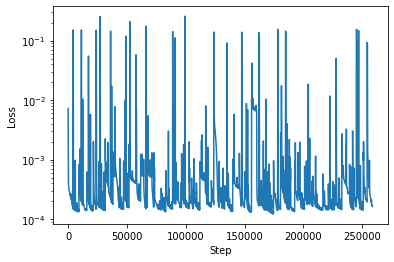

In [25]:
plt.plot([x*100 for x in range(len(lossList))], lossList)
plt.ylabel('Loss')
plt.xlabel('Step')
plt.yscale("log")
plt.show()

## Result

### best parameters

In [26]:
ys = cls_predict(xs, 50, best_params)

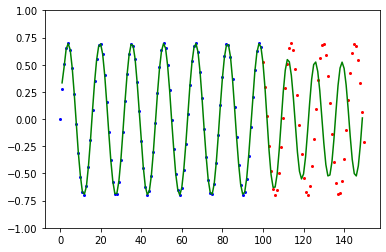

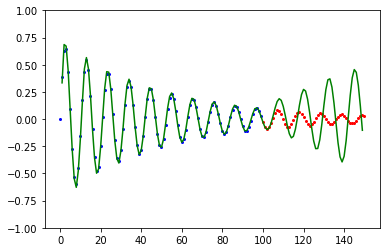

In [27]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

### final parameters

In [28]:
ys = cls_predict(xs, 50, params)

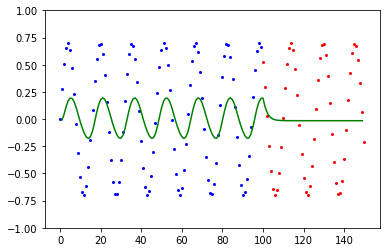

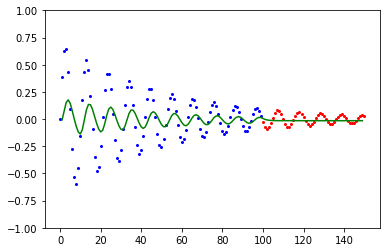

In [29]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

## Load & find the best parameters

In [22]:
# load
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'rb') as f:
    lossList, minLoss, params, best_params, loc_params_list, reset_steps = pickle.load(f)

In [23]:
test_result = []
min_loss = 1000
k = 0
for i in reset_steps[1:]:
    k += 1
    j = int(i/100 -1)
    i_loss = lossList[j]
    i_params = loc_params_list[k]
    
    ys = cls_predict(xs, 50, i_params)
    
    t_loss = jnp.mean((true2[:,:-1]-ys[:,-50:,0])**2)
    test_result.append([i,i_loss,t_loss,i_params,ys])
    if t_loss < min_loss:
        min_loss = t_loss
        min_idx = k-1
        min_ys = ys
        
test_result[min_idx]

[183200,
 Array(0.0002721, dtype=float64),
 Array(0.08193559, dtype=float64),
 [((Array([[-1.58047828,  3.44808578]], dtype=float64),
    Array([[ 0.017123  , -1.92317758],
           [-1.81897391,  5.04264547]], dtype=float64),
    Array([ 0.8635304 , -5.81733613], dtype=float64)),
   (Array([[-2.51390501, -0.89811387]], dtype=float64),
    Array([[ 0.81901241, -3.70989102],
           [-3.74883244,  0.43027174]], dtype=float64),
    Array([0.92494445, 1.94744715], dtype=float64)),
   (Array([[ 0.01700901, -1.40357335]], dtype=float64),
    Array([[-4.21394502, -2.66142032],
           [ 1.96080215, -0.82776322]], dtype=float64),
    Array([-0.31504748, -0.19218199], dtype=float64))),
  (Array([[ 0.38527646],
          [-1.89605619]], dtype=float64),
   Array([0.0016012], dtype=float64))],
 Array([[[ 3.25644314e-01],
         [ 4.30155260e-01],
         [ 6.68718851e-01],
         [ 6.87218995e-01],
         [ 6.21080874e-01],
         [ 4.83232237e-01],
         [ 2.17679736e-01],
  

In [24]:
# Save results
# [[i,i_loss,t_loss,i_params,ys]...]
with open(nb_name+'_test_result.pkl', 'wb') as f:
    pickle.dump(test_result, f)

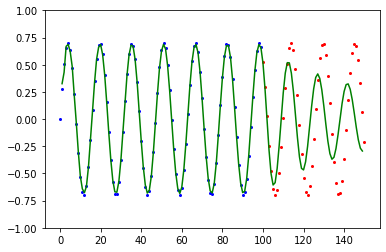

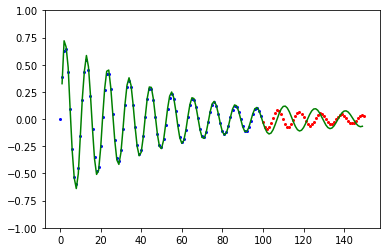

In [32]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(min_ys[idx])))+1, min_ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

best: [183200, Array(0.0002721, dtype=float64), Array(0.08193559, dtype=float64)]
9300 0.0001342357537590326 0.18721850412437138


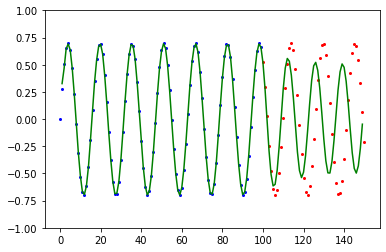

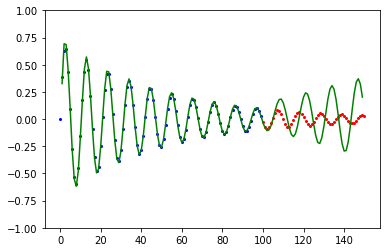

16000 0.00014100785313757002 0.13174831156579603


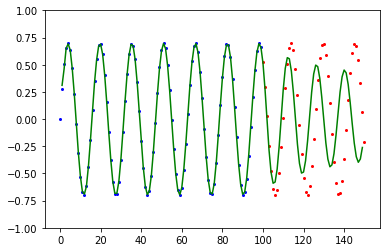

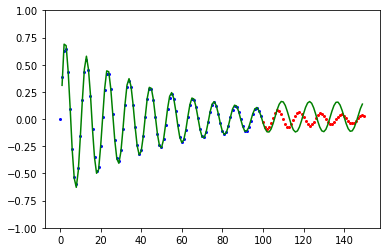

21500 0.0001394212058521033 0.15261955612341396


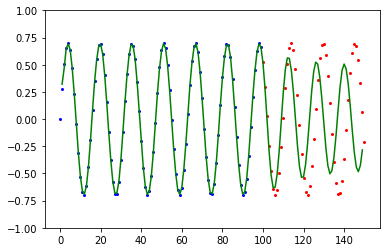

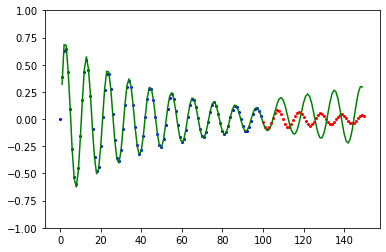

26300 0.00015927259558783506 0.1505452838799909


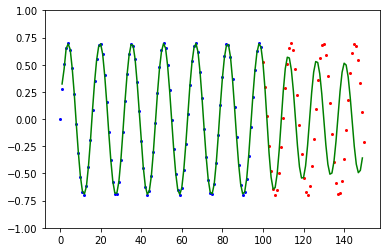

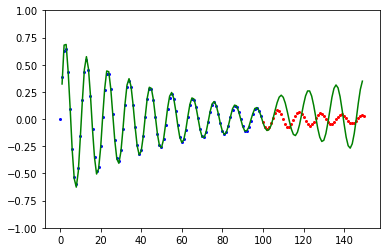

31600 0.00014037854021469525 0.15701844004989035


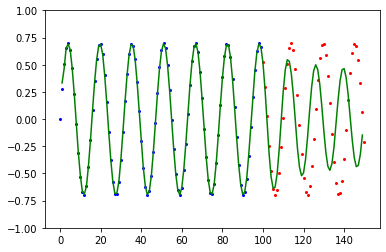

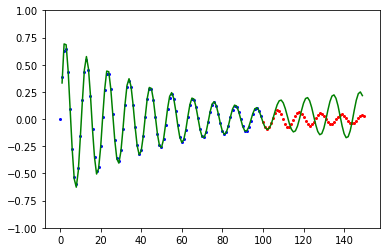

38200 0.00017844725829578142 0.12660869575985015


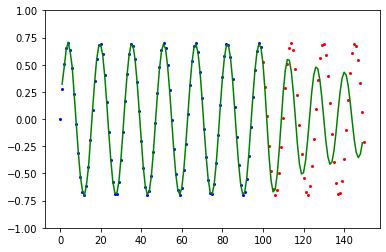

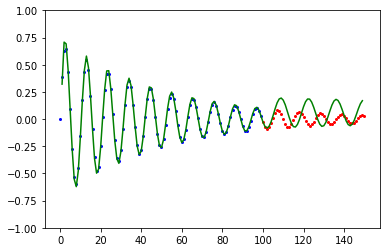

47200 0.00014674134798182143 0.18292519214637143


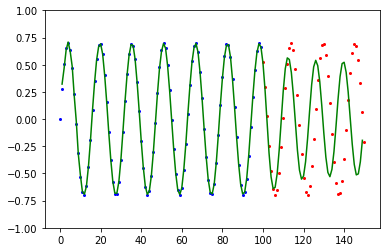

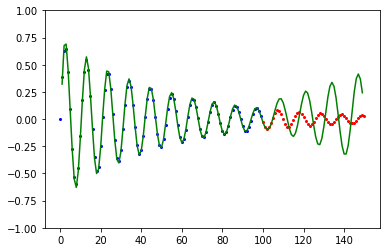

51800 0.0001558075437601733 0.1533139667035637


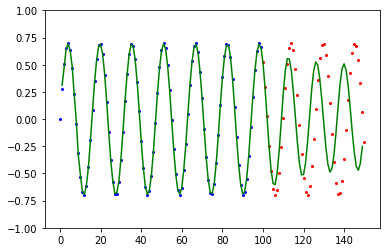

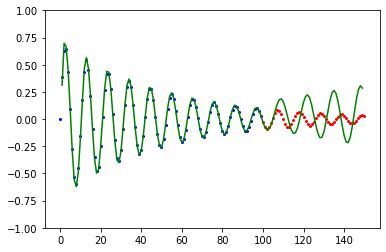

57700 0.0004015298856242647 0.1602043715769618


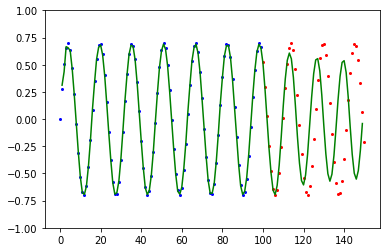

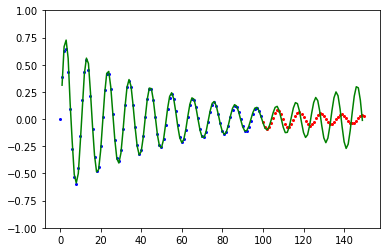

61700 0.00020088321124893258 0.11386913190849189


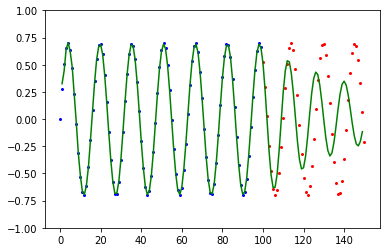

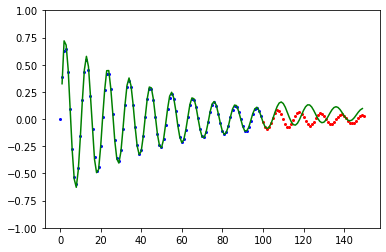

64200 0.0005161658466189341 0.13400883239944056


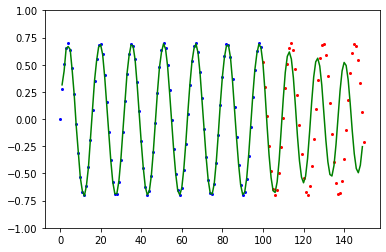

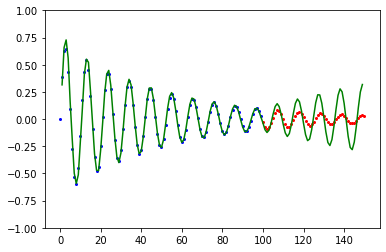

67400 0.00015865507719582436 0.13925419917023793


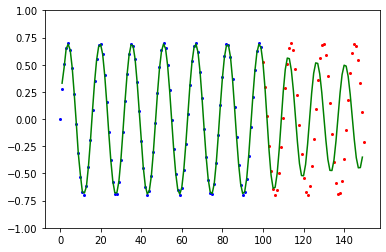

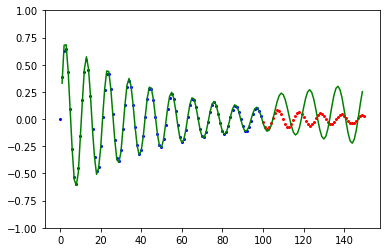

71100 0.0005124320315089824 0.1651273248259739


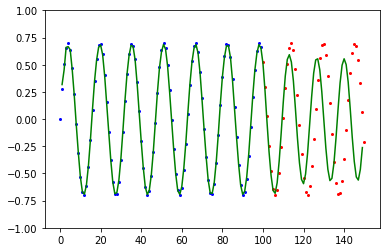

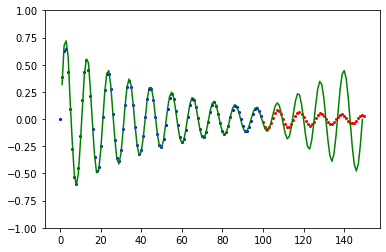

79200 0.00014409861125620993 0.16070437954566935


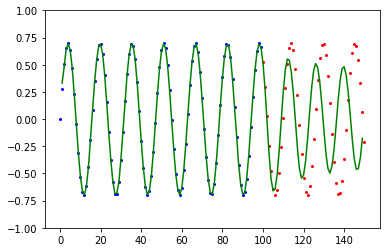

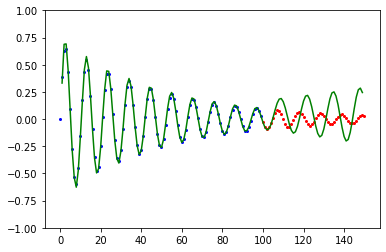

83100 0.00013351097388115258 0.16853473032348276


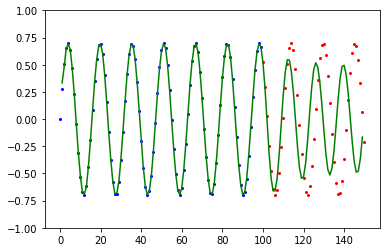

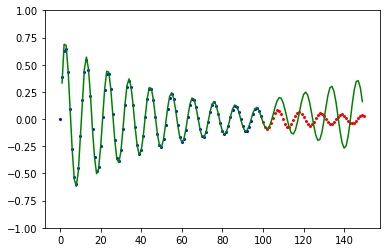

88900 0.00014900006443838065 0.13268524768240622


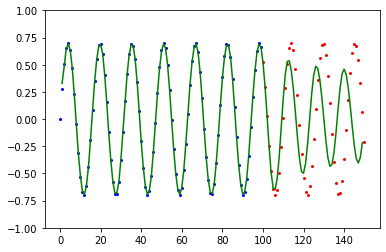

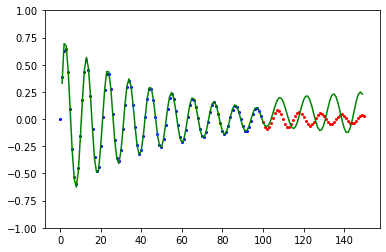

91600 0.0001805873860767903 0.15412089262748058


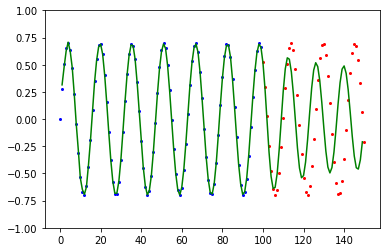

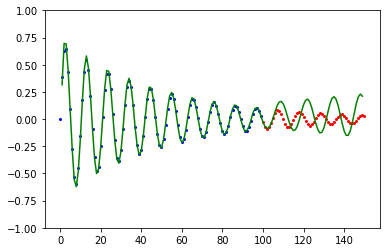

96500 0.0001565156514963397 0.11606218104823195


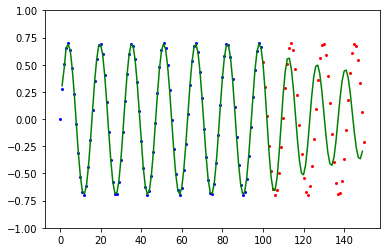

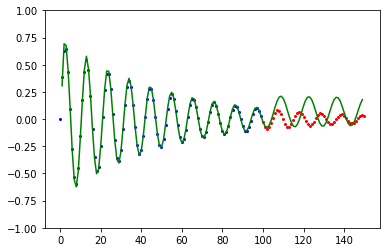

103000 0.00015143860237012803 0.16735642163044734


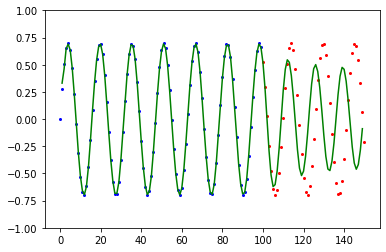

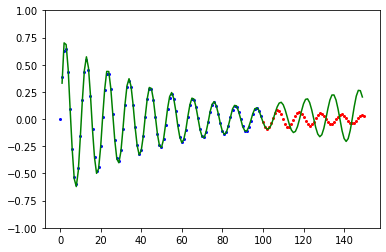

106500 0.00014971777355793248 0.1574639691809691


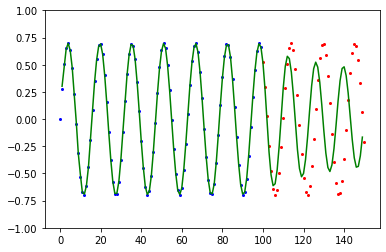

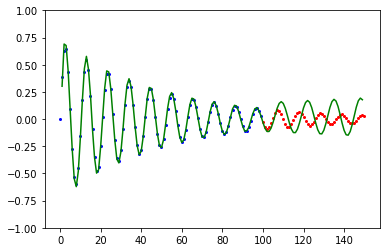

112100 0.0001446118259815738 0.14711557985862267


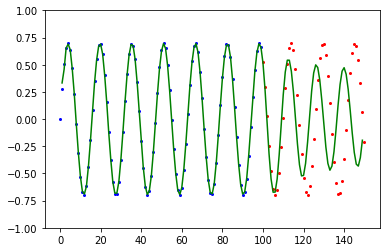

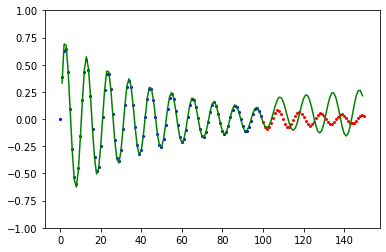

116700 0.0004471190400925049 0.1435450333982864


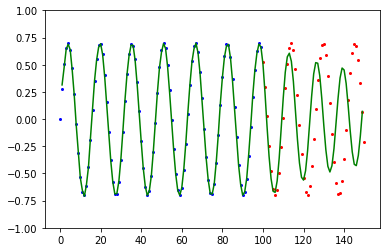

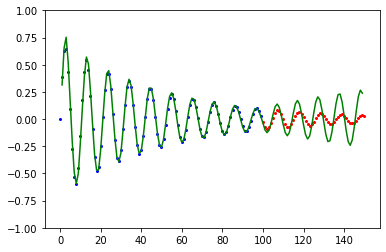

121800 0.00016128744276742212 0.12079696457997788


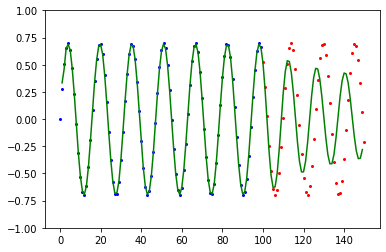

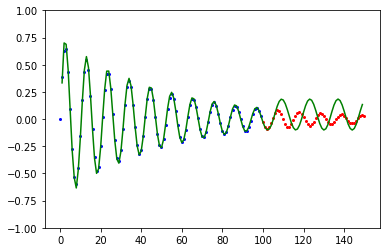

128500 0.00015944098914914427 0.10751946727552585


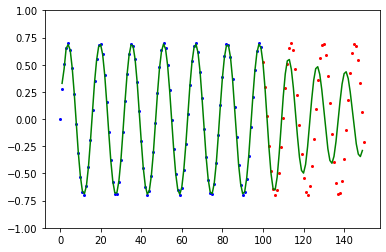

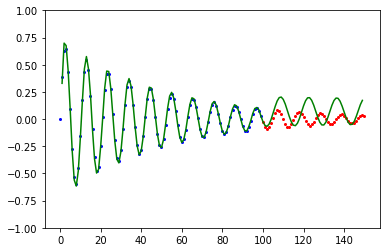

133200 0.00014814832534777633 0.146772621995665


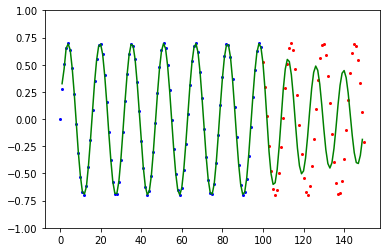

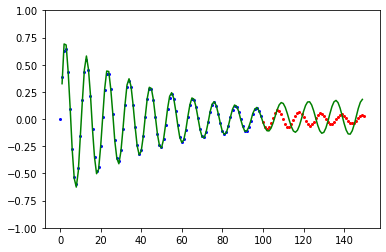

140000 0.00013515016421453239 0.1866312931234533


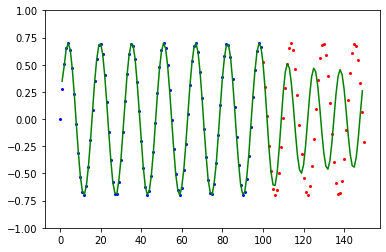

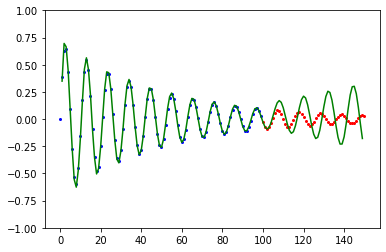

145600 0.0003338536456633224 0.10823589135819918


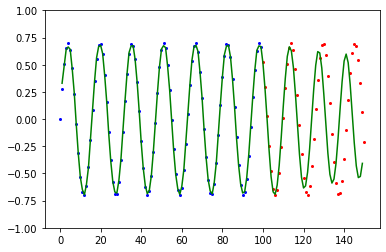

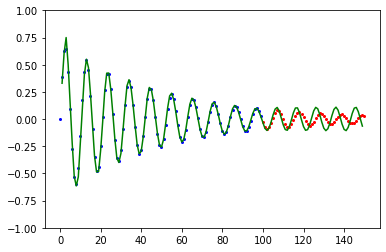

150100 0.00015712498721293097 0.1627745115772551


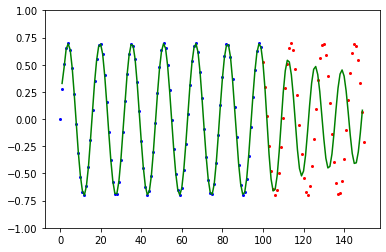

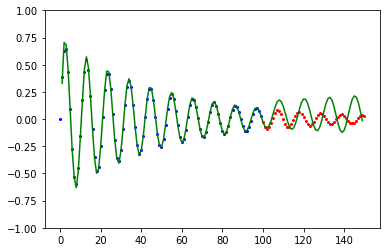

156000 0.0001336907260600459 0.21762719919590617


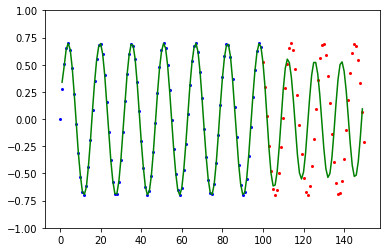

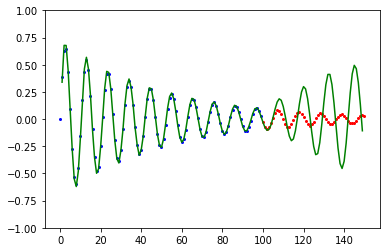

160400 0.006639246389661363 0.1401874658146726


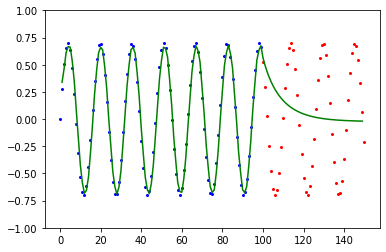

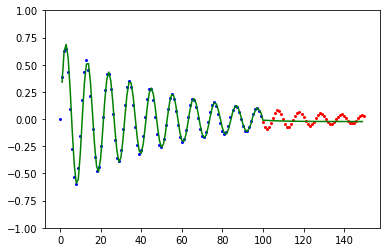

164200 0.00016964297969736142 0.12649168225186752


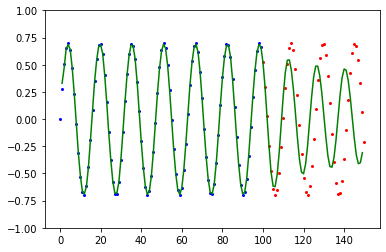

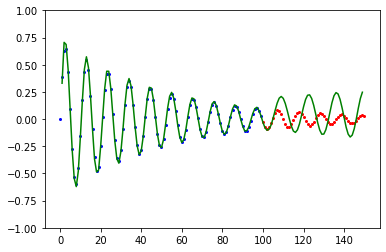

169300 0.00014218963773442866 0.159291999997096


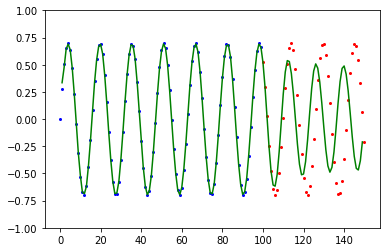

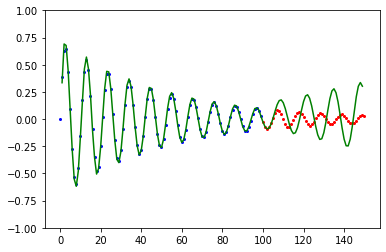

174700 0.0001231168185187368 0.20217159101607363


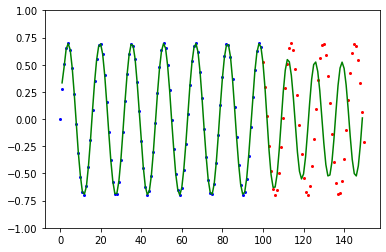

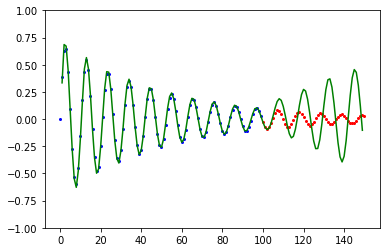

180700 0.00014622650220194212 0.14986602614394653


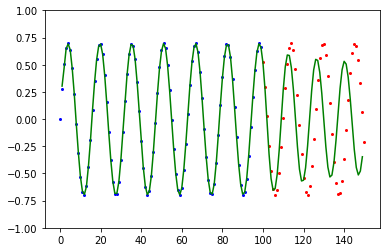

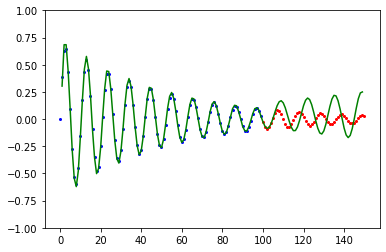

183200 0.00027210392227533915 0.08193559115474269


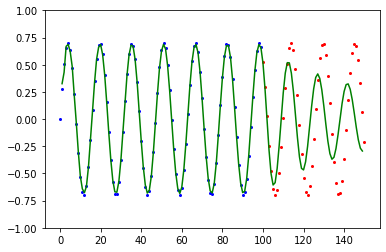

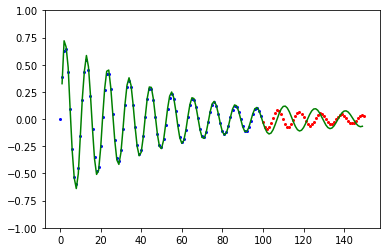

188100 0.00014535023732608826 0.13699223587134268


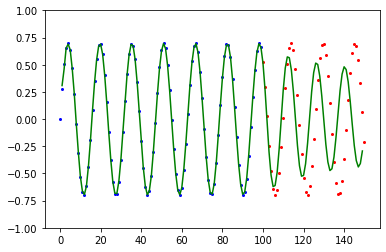

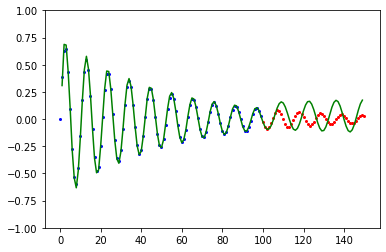

192700 0.0001352566025290445 0.17840565831618652


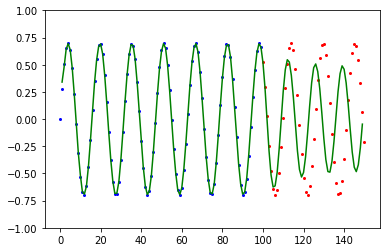

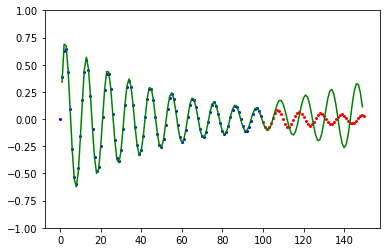

195400 0.0002066575835942771 0.15270906045286795


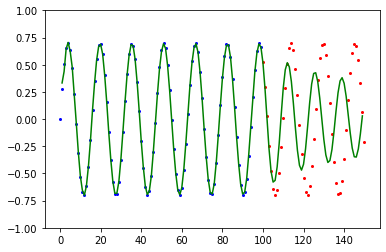

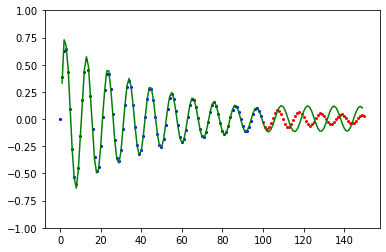

201100 0.00014737472038007629 0.1602449655974779


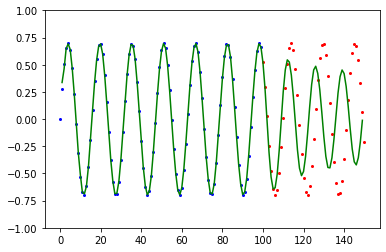

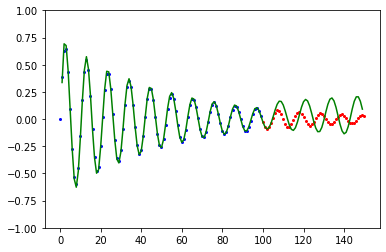

205300 0.00017926431337925036 0.15480579626834712


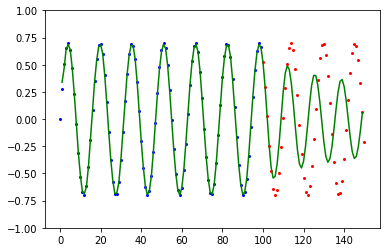

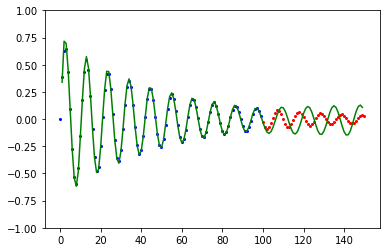

208200 0.00016470176113593545 0.13508074497836967


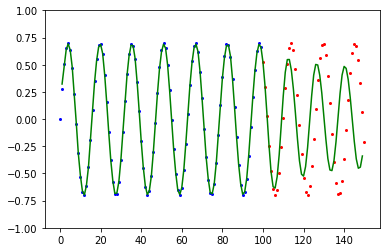

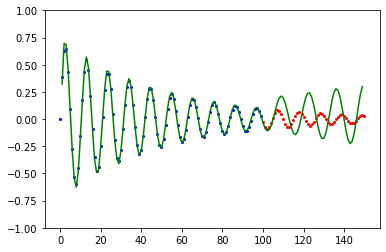

216700 0.000143254150532505 0.13550766536166853


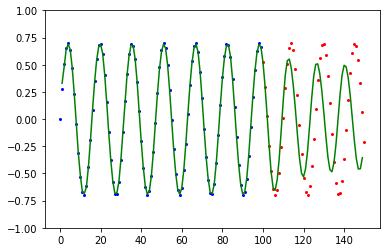

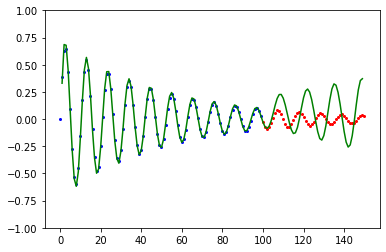

221300 0.00014379595157485998 0.14815667870284321


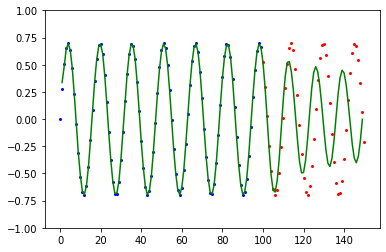

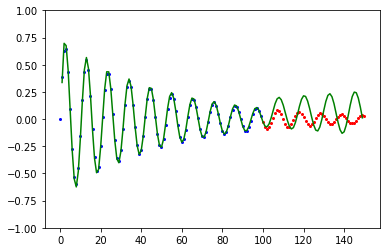

226300 0.00014454625410574947 0.15378333066375496


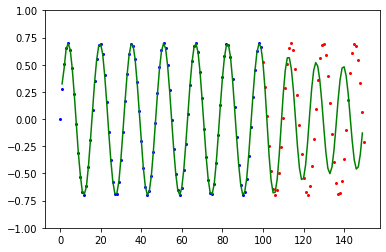

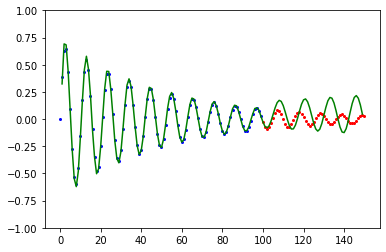

232800 0.0001463722768829736 0.13005804553941563


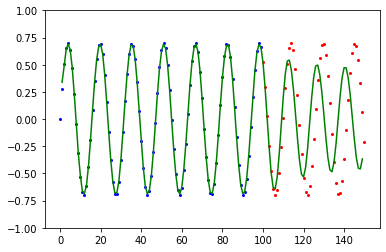

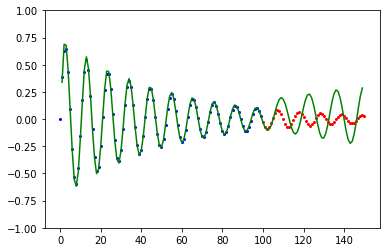

239300 0.0002655620868382774 0.17964253879981712


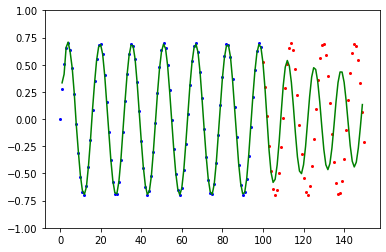

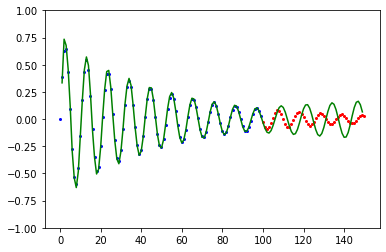

242900 0.00014453580939581632 0.14409382332186288


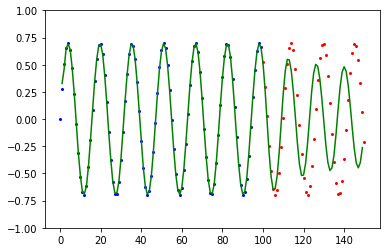

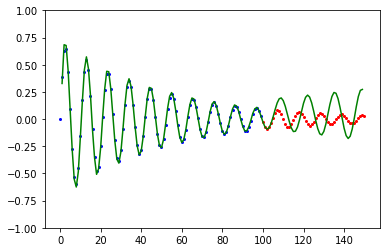

245800 0.09802932839991303 0.09995012633559082


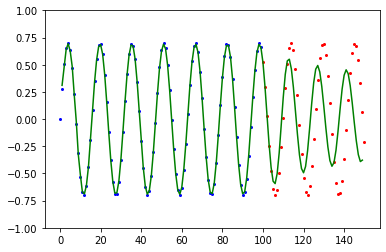

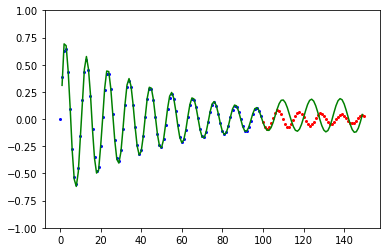

251000 0.00014319241330004845 0.15959816703284443


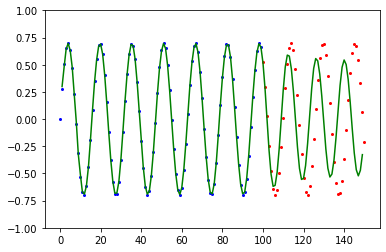

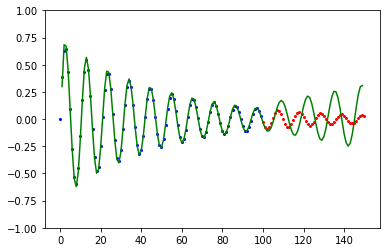

258900 0.00016353635704186538 0.18680061095015352


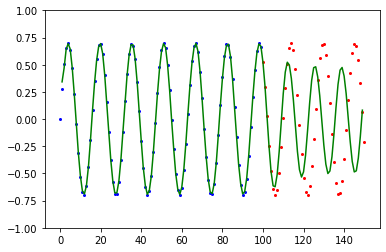

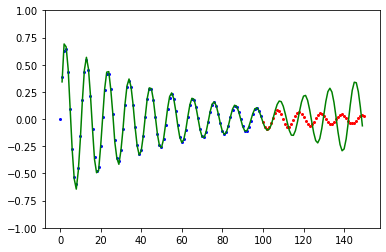

In [33]:
print('best:', test_result[min_idx][0:3])
for pak in test_result:
    i, i_loss, t_loss, _, ys = pak
    print(i, i_loss, t_loss)
    for idx in [0, 1]:
        plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
        plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
        plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
        plt.ylim(-1,1)
        plt.show()

In [34]:
sum([_[2] for _ in test_result])/len(test_result)

Array(0.14936364, dtype=float64)

In [35]:
len(test_result)

50